# BÀI THỰC HÀNH 01: GIẢM SỐ CHIỀU DỮ LIỆU (PCA, PCA+SVD & LDA)
**Môn học:** Học Máy (Machine Learning) 

**Họ và tên:** Nguyễn Đỗ Thắng

**MSSV:** 102230046

**Lớp SH:** 23T_NHAT1

**Nội dung:**
- **Exercise 01:** Dimensionality Reduction with PCA and PCA+SVD (Chuẩn hóa ma trận hiệp phương sai và phân rã giá trị suy biến)
- **Exercise 02:** Linear Discriminant Analysis (LDA) trên tập dữ liệu Iris

---

## 1. EXERCISE 01: DIMENSIONALITY REDUCTION WITH PCA AND PCA+SVD

### Dữ liệu ban đầu:
Cho tập dữ liệu 2D với $N = 4$ mẫu, biểu diễn bởi ma trận $X \in \mathbb{R}^{2 \times 4}$:
$$X = \begin{bmatrix} 2 & 3 & 5 & 6 \\ 1 & 5 & 4 & 6 \end{bmatrix}$$
- Hàng 1: Đặc trưng $x_1$
- Hàng 2: Đặc trưng $x_2$
- Mỗi cột tương ứng với một mẫu dữ liệu $X_i$.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Khởi tạo dữ liệu X (2x4)
X = np.array([
    [2.0, 3.0, 5.0, 6.0],
    [1.0, 5.0, 4.0, 6.0]
])

N = X.shape[1] # Số mẫu = 4
d = X.shape[0] # Số chiều = 2

print("Dữ liệu gốc X (2x4):")
print(X)

Dữ liệu gốc X (2x4):
[[2. 3. 5. 6.]
 [1. 5. 4. 6.]]


### Q1: Standard PCA via Covariance Matrix (8 bước)
1. **Bước 1:** Tính vector kỳ vọng $\mu$.
2. **Bước 2:** Trừ trung bình $\tilde{X} = X - \mu$.
3. **Bước 3:** Tính ma trận hiệp phương sai $C = \frac{1}{N-1} \tilde{X}\tilde{X}^T$.
4. **Bước 4:** Tìm trị riêng $\lambda$ và vector riêng của $C$.
5. **Bước 5:** Sắp xếp $\lambda$ giảm dần và chọn vector riêng chính $v_1$ (PC1).
6. **Bước 6:** Chiếu dữ liệu sang không gian 1D: $Z = v_1^T \tilde{X}$.
7. **Bước 7:** Tái tạo lại dữ liệu gốc: $X_{\text{reconstructed}} = v_1 Z + \mu$.
8. **Bước 8:** Đánh giá phương sai giải thích và sai số tái tạo.

In [40]:
# Step 1: Vector trung bình mu
mu_pca = np.mean(X, axis=1, keepdims=True)
print("[Step 1] Mean vector mu:\n", mu_pca)

# Step 2: Dữ liệu đã trừ trung bình (Zero-centered)
X_tilde_pca = X - mu_pca
print("\n[Step 2] Centered data X_tilde:\n", X_tilde_pca)

# Step 3: Ma trận hiệp phương sai C
C = (1 / (N - 1)) * (X_tilde_pca @ X_tilde_pca.T)
print("\n[Step 3] Covariance Matrix C:\n", C)

# Step 4: Trị riêng và Vector riêng của C
eig_vals_pca, eig_vecs_pca = np.linalg.eigh(C)
print("\n[Step 4] Trị riêng ban đầu:", eig_vals_pca)

# Step 5: Sắp xếp giảm dần và chọn PC1 (v1)
idx_sort = np.argsort(eig_vals_pca)[::-1]
eig_vals_pca = eig_vals_pca[idx_sort]
eig_vecs_pca = eig_vecs_pca[:, idx_sort]

pc1_vector = eig_vecs_pca[:, 0:1]
if pc1_vector[0, 0] < 0:
    pc1_vector = -pc1_vector

print("\n[Step 5] Trị riêng sau sắp xếp:", eig_vals_pca)
print("Vector thành phần chính PC1 (v1):\n", pc1_vector)

# Step 6: Tọa độ 1D sau khi chiếu
Z_pca = pc1_vector.T @ X_tilde_pca
print("\n[Step 6] Tọa độ 1D (Z = v1.T @ X_tilde):\n", Z_pca)

# Step 7: Tái tạo dữ liệu
X_reconstructed_pca = pc1_vector @ Z_pca + mu_pca
print("\n[Step 7] Dữ liệu tái tạo (X_reconstructed):\n", X_reconstructed_pca)

# Step 8: Đánh giá phương sai & sai số
explained_var_ratio = eig_vals_pca[0] / np.sum(eig_vals_pca) * 100
mse_pca = np.mean(np.sum((X - X_reconstructed_pca)**2, axis=0))
print(f"\n[Step 8] Tỷ lệ phương sai giải thích được bởi PC1: {explained_var_ratio:.2f}%")
print(f"Sai số tái tạo trung bình (MSE): {mse_pca:.4f}")

[Step 1] Mean vector mu:
 [[4.]
 [4.]]

[Step 2] Centered data X_tilde:
 [[-2. -1.  1.  2.]
 [-3.  1.  0.  2.]]

[Step 3] Covariance Matrix C:
 [[3.33333333 3.        ]
 [3.         4.66666667]]

[Step 4] Trị riêng ban đầu: [0.92681851 7.07318149]

[Step 5] Trị riêng sau sắp xếp: [7.07318149 0.92681851]
Vector thành phần chính PC1 (v1):
 [[0.62572739]
 [0.78004181]]

[Step 6] Tọa độ 1D (Z = v1.T @ X_tilde):
 [[-3.59158022  0.15431442  0.62572739  2.81153841]]

[Step 7] Dữ liệu tái tạo (X_reconstructed):
 [[1.75264987 4.09655876 4.39153477 5.7592566 ]
 [1.19841725 4.1203717  4.48809353 6.19311752]]

[Step 8] Tỷ lệ phương sai giải thích được bởi PC1: 88.41%
Sai số tái tạo trung bình (MSE): 0.6951


### Q2: PCA using SVD (8 bước)
Triển khai trực tiếp phân rã SVD trên ma trận dữ liệu đã chuẩn hóa tâm $\tilde{X} = U \Sigma V^T$.

In [41]:
# Step 1: Vector trung bình mu
mu_svd = np.mean(X, axis=1, keepdims=True)
print("[Step 1] Mean vector mu:\n", mu_svd)

# Step 2: Dữ liệu đã trừ trung bình
X_tilde_svd = X - mu_svd
print("\n[Step 2] Centered data matrix X_tilde:\n", X_tilde_svd)

# Step 3 & 4: Phân rã SVD X_tilde = U * S * Vt
U, S, Vt = np.linalg.svd(X_tilde_svd, full_matrices=False)
print("\n[Step 4] SVD Results:")
print("Ma trận U (Left singular vectors):\n", U)
print("Các giá trị suy biến S (Singular values):", S)
print("Ma trận V^T (Right singular vectors):\n", Vt)

# Step 5: Xác định PC1 từ U[:, 0] và quy đổi trị riêng tương đương
u1 = U[:, 0:1]
if np.dot(u1.flatten(), pc1_vector.flatten()) < 0:
    u1 = -u1
    Vt[0, :] = -Vt[0, :]

lambda_svd = (S**2) / (N - 1)
print("\n[Step 5] PC1 vector từ U[:, 0]:\n", u1)
print("Trị riêng tương đương S^2 / (N-1):", lambda_svd)

# Step 6: Tọa độ 1D sau khi chiếu
Z_svd = u1.T @ X_tilde_svd
print("\n[Step 6] 1D Coordinates Z_svd:\n", Z_svd)

# Step 7: Tái tạo dữ liệu
X_reconstructed_svd = u1 @ Z_svd + mu_svd
print("\n[Step 7] Dữ liệu tái tạo X_reconstructed_svd:\n", X_reconstructed_svd)

# Step 8: Đối chiếu độ sai lệch giữa PCA và SVD
diff_recon = np.max(np.abs(X_reconstructed_pca - X_reconstructed_svd))
print(f"\n[Step 8] Độ sai khác cực đại giữa PCA Covariance và PCA SVD: {diff_recon:.2e}")
print("=> Kết luận: Phương pháp SVD cho kết quả hoàn toàn đồng nhất với PCA truyền thống.")

[Step 1] Mean vector mu:
 [[4.]
 [4.]]

[Step 2] Centered data matrix X_tilde:
 [[-2. -1.  1.  2.]
 [-3.  1.  0.  2.]]

[Step 4] SVD Results:
Ma trận U (Left singular vectors):
 [[-0.62572739 -0.78004181]
 [-0.78004181  0.62572739]]
Các giá trị suy biến S (Singular values): [4.60646768 1.6674698 ]
Ma trận V^T (Right singular vectors):
 [[ 0.77968206 -0.03349951 -0.13583671 -0.61034585]
 [-0.1901675   0.84305527 -0.46779966 -0.18508811]]

[Step 5] PC1 vector từ U[:, 0]:
 [[0.62572739]
 [0.78004181]]
Trị riêng tương đương S^2 / (N-1): [7.07318149 0.92681851]

[Step 6] 1D Coordinates Z_svd:
 [[-3.59158022  0.15431442  0.62572739  2.81153841]]

[Step 7] Dữ liệu tái tạo X_reconstructed_svd:
 [[1.75264987 4.09655876 4.39153477 5.7592566 ]
 [1.19841725 4.1203717  4.48809353 6.19311752]]

[Step 8] Độ sai khác cực đại giữa PCA Covariance và PCA SVD: 8.88e-16
=> Kết luận: Phương pháp SVD cho kết quả hoàn toàn đồng nhất với PCA truyền thống.


### Q3: Visualization (Trực quan hóa đồ thị 2 Subplots)
- Điểm gốc $X$
- Tâm $\mu$
- Điểm tái tạo $X_{\text{reconstructed}}$
- Trục PC1 nét đứt đỏ (*red dashed*)
- Đường gióng vuông góc nối từ $X_i$ đến điểm chiếu (*dotted gray*)

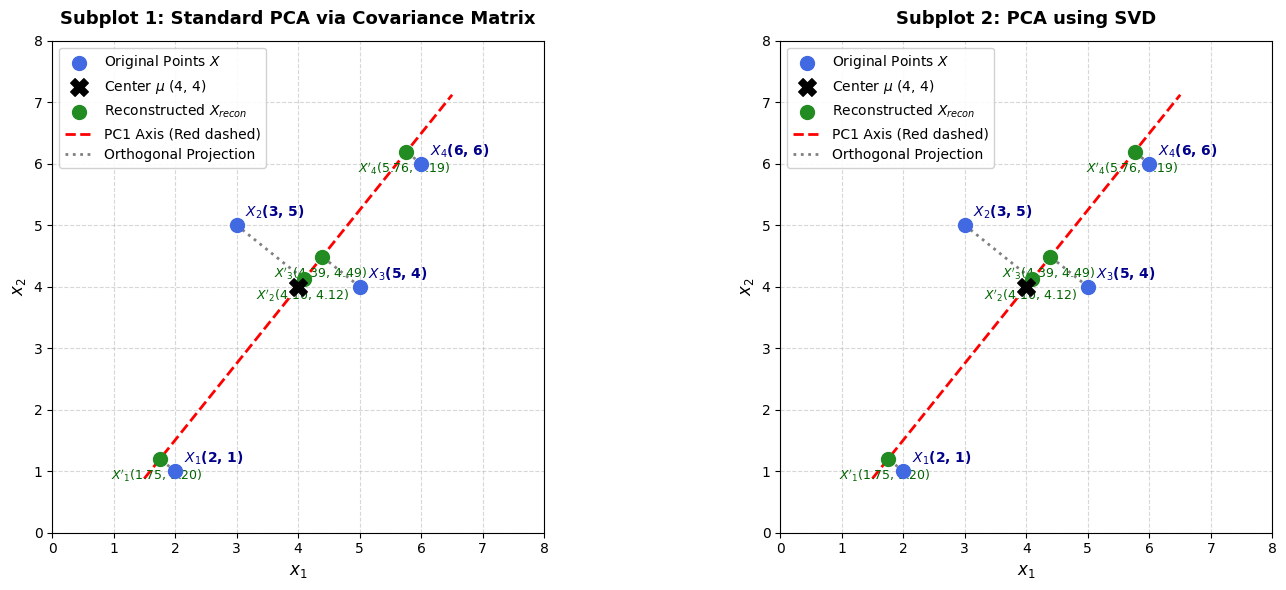

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def plot_pca_subplot(ax, X_orig, mu, X_recon, pc_vec, title):
    ax.scatter(X_orig[0, :], X_orig[1, :], color='royalblue', s=100, zorder=5, label='Original Points $X$')
    ax.scatter(mu[0], mu[1], color='black', marker='X', s=160, zorder=6, label=r'Center $\mu$ (4, 4)')
    ax.scatter(X_recon[0, :], X_recon[1, :], color='forestgreen', s=100, marker='o', zorder=5, label='Reconstructed $X_{recon}$')
    
    # Trục PC1 nét đứt đỏ
    t_vals = np.linspace(-4, 4, 100)
    pc1_line = mu + pc_vec * t_vals
    ax.plot(pc1_line[0, :], pc1_line[1, :], 'r--', linewidth=2, label='PC1 Axis (Red dashed)')
    
    # Đường gióng trực giao màu xám
    for i in range(X_orig.shape[1]):
        ax.plot([X_orig[0, i], X_recon[0, i]], 
                [X_orig[1, i], X_recon[1, i]], 
                color='gray', linestyle=':', linewidth=2,
                label='Orthogonal Projection' if i == 0 else "")
        ax.annotate(f'$X_{i+1}$({X_orig[0, i]:.0f}, {X_orig[1, i]:.0f})', 
                    (X_orig[0, i], X_orig[1, i]), 
                    textcoords="offset points", xytext=(6, 6), fontsize=10, color='darkblue', fontweight='bold')
        ax.annotate(f'$X\'_{i+1}$({X_recon[0, i]:.2f}, {X_recon[1, i]:.2f})', 
                    (X_recon[0, i], X_recon[1, i]), 
                    textcoords="offset points", xytext=(-35, -15), fontsize=9, color='darkgreen')
    
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 8)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='upper left', framealpha=0.9)

# Subplot 1
plot_pca_subplot(axes[0], X, mu_pca, X_reconstructed_pca, pc1_vector, 'Subplot 1: Standard PCA via Covariance Matrix')
# Subplot 2
plot_pca_subplot(axes[1], X, mu_svd, X_reconstructed_svd, u1, 'Subplot 2: PCA using SVD')

plt.tight_layout()
plt.show()

---
## 2. EXERCISE 02: LINEAR DISCRIMINANT ANALYSIS (LDA)

### Dữ liệu:
Chọn 10 mẫu từ tập dữ liệu Iris thuộc 2 loài: **Setosa** (5 mẫu) và **Versicolor** (5 mẫu), mỗi mẫu gồm $d=4$ đặc trưng.

In [43]:
data_iris = {
    'sepal length (cm)': [4.3, 5.1, 4.8, 4.8, 5.1, 6.1, 5.5, 5.5, 5.7, 5.8],
    'sepal width (cm)':  [3.0, 3.4, 3.1, 3.0, 3.5, 2.9, 2.5, 2.4, 3.0, 2.7],
    'petal length (cm)': [1.1, 1.5, 1.6, 1.4, 1.4, 4.7, 4.0, 3.8, 4.2, 4.1],
    'petal width (cm)':  [0.1, 0.2, 0.2, 0.3, 0.3, 1.4, 1.3, 1.1, 1.2, 1.0],
    'species': ['setosa'] * 5 + ['versicolor'] * 5
}

df = pd.DataFrame(data_iris)
feature_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

X_setosa = df[df['species'] == 'setosa'][feature_cols].values
X_versicolor = df[df['species'] == 'versicolor'][feature_cols].values
X_all = df[feature_cols].values

N1, N2, d = len(X_setosa), len(X_versicolor), len(feature_cols)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,4.3,3.0,1.1,0.1,setosa
1,5.1,3.4,1.5,0.2,setosa
2,4.8,3.1,1.6,0.2,setosa
3,4.8,3.0,1.4,0.3,setosa
4,5.1,3.5,1.4,0.3,setosa
5,6.1,2.9,4.7,1.4,versicolor
6,5.5,2.5,4.0,1.3,versicolor
7,5.5,2.4,3.8,1.1,versicolor
8,5.7,3.0,4.2,1.2,versicolor
9,5.8,2.7,4.1,1.0,versicolor


### Step-by-Step LDA Algorithm (5 bước)
- **Step 1:** Tính vector trung bình $\mu_i$, ma trận tán xạ trong từng lớp $S_i$ và tổng $S_W = S_1 + S_2$.
- **Step 2:** Tính trung bình toàn cục $\mu$ và ma trận tán xạ giữa các lớp $S_B$.
- **Step 3:** Giải bài toán trị riêng tổng quát cho $(S_W^{-1} S_B) w = \lambda w$.
- **Step 4:** Chọn vector riêng trội làm ma trận chiếu $W$, tính tọa độ 1D $y = W^T x$.
- **Step 5:** Vẽ biểu đồ trực quan hóa phân tách 1D.

In [44]:
# ==========================================
# STEP 1: CLASS MEAN VECTORS & S_W
# ==========================================
mu1 = np.mean(X_setosa, axis=0, keepdims=True).T      # Setosa mean (4x1)
mu2 = np.mean(X_versicolor, axis=0, keepdims=True).T  # Versicolor mean (4x1)

print("[Step 1] Mean vector mu1 (Setosa):\n", mu1)
print("\n[Step 1] Mean vector mu2 (Versicolor):\n", mu2)

# Tính S1
S1 = np.zeros((d, d))
for row in X_setosa:
    diff = row.reshape(-1, 1) - mu1
    S1 += diff @ diff.T

# Tính S2
S2 = np.zeros((d, d))
for row in X_versicolor:
    diff = row.reshape(-1, 1) - mu2
    S2 += diff @ diff.T

S_W = S1 + S2
print("\nWithin-class Scatter Matrix S1 (Setosa):\n", np.round(S1, 4))
print("\nWithin-class Scatter Matrix S2 (Versicolor):\n", np.round(S2, 4))
print("\nOverall Within-class Scatter Matrix S_W:\n", np.round(S_W, 4))

# ==========================================
# STEP 2: GLOBAL MEAN & S_B
# ==========================================
mu = np.mean(X_all, axis=0, keepdims=True).T
diff1 = mu1 - mu
diff2 = mu2 - mu
S_B = N1 * (diff1 @ diff1.T) + N2 * (diff2 @ diff2.T)

print("\n[Step 2] Global Mean Vector mu:\n", mu)
print("\nBetween-class Scatter Matrix S_B:\n", np.round(S_B, 4))

# ==========================================
# STEP 3: EIGENVALUE PROBLEM FOR S_W^{-1} S_B
# ==========================================
S_W_inv = np.linalg.inv(S_W)
eig_vals_lda, eig_vecs_lda = np.linalg.eig(S_W_inv @ S_B)
eig_vals_lda = np.real(eig_vals_lda)
eig_vecs_lda = np.real(eig_vecs_lda)

print("\n[Step 3] Các trị riêng lambda_i và vector riêng w_i:")
for i in range(d):
    print(f"  lambda_{i+1} = {eig_vals_lda[i]:.6f} | w_{i+1} = {np.round(eig_vecs_lda[:, i], 4)}")

# ==========================================
# STEP 4: PROJECTION MATRIX W & 1D COORDS
# ==========================================
idx_best = np.argmax(eig_vals_lda)
W = eig_vecs_lda[:, idx_best:idx_best+1]
W = W / np.linalg.norm(W) # Chuẩn hóa độ dài vector W

# Đảm bảo hướng dương phân tách
if (mu2.T @ W)[0, 0] < (mu1.T @ W)[0, 0]:
    W = -W

print("\n[Step 4] Vector chiếu W (Leading Eigenvector):\n", np.round(W, 6))

y_all = (X_all @ W).flatten()
df['1D Transformed (y)'] = np.round(y_all, 4)
print("\nBảng kết quả tọa độ 1D sau khi chiếu:")
print(df[['species', '1D Transformed (y)']])

[Step 1] Mean vector mu1 (Setosa):
 [[4.82]
 [3.2 ]
 [1.4 ]
 [0.22]]

[Step 1] Mean vector mu2 (Versicolor):
 [[5.72]
 [2.7 ]
 [4.16]
 [1.2 ]]

Within-class Scatter Matrix S1 (Setosa):
 [[0.428 0.25  0.18  0.078]
 [0.25  0.22  0.06  0.03 ]
 [0.18  0.06  0.14  0.03 ]
 [0.078 0.03  0.03  0.028]]

Within-class Scatter Matrix S2 (Versicolor):
 [[0.248 0.18  0.314 0.06 ]
 [0.18  0.26  0.26  0.05 ]
 [0.314 0.26  0.452 0.14 ]
 [0.06  0.05  0.14  0.1  ]]

Overall Within-class Scatter Matrix S_W:
 [[0.676 0.43  0.494 0.138]
 [0.43  0.48  0.32  0.08 ]
 [0.494 0.32  0.592 0.17 ]
 [0.138 0.08  0.17  0.128]]

[Step 2] Global Mean Vector mu:
 [[5.27]
 [2.95]
 [2.78]
 [0.71]]

Between-class Scatter Matrix S_B:
 [[ 2.025 -1.125  6.21   2.205]
 [-1.125  0.625 -3.45  -1.225]
 [ 6.21  -3.45  19.044  6.762]
 [ 2.205 -1.225  6.762  2.401]]

[Step 3] Các trị riêng lambda_i và vector riêng w_i:
  lambda_1 = -0.000000 | w_1 = [-0.9496 -0.162   0.2647  0.044 ]
  lambda_2 = 66.582778 | w_2 = [-0.1859 -0.5079  0

### Step 5: Trực quan hóa kết quả phân tách 1D

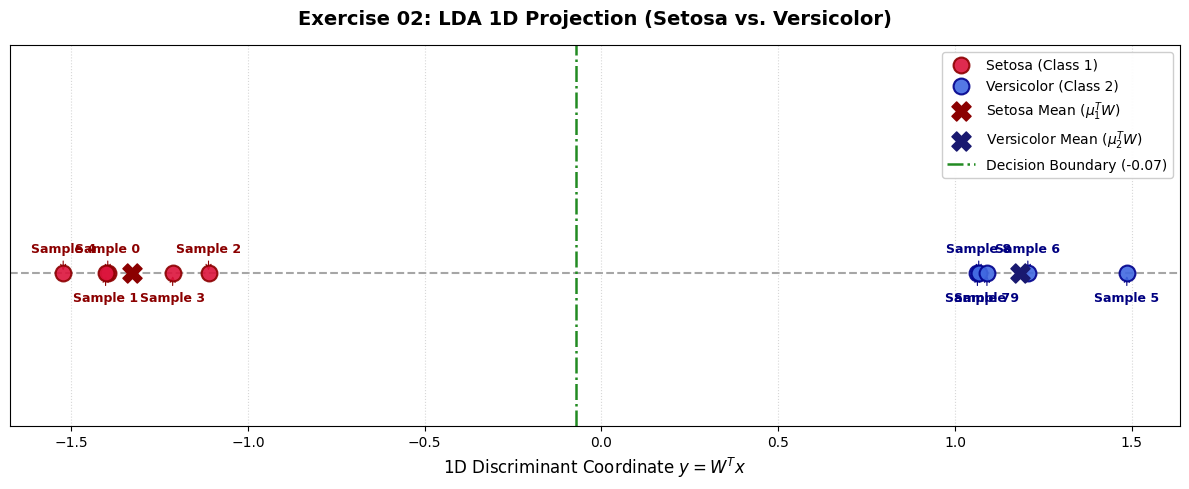

In [45]:
plt.figure(figsize=(12, 5))

y_setosa = y_all[:5]
y_versicolor = y_all[5:]

plt.axhline(0, color='gray', linestyle='--', alpha=0.7, zorder=1)

plt.scatter(y_setosa, np.zeros_like(y_setosa), color='crimson', s=130, alpha=0.9, 
            edgecolors='darkred', linewidth=1.5, label='Setosa (Class 1)', zorder=4)

plt.scatter(y_versicolor, np.zeros_like(y_versicolor), color='royalblue', s=130, alpha=0.9, 
            edgecolors='darkblue', linewidth=1.5, label='Versicolor (Class 2)', zorder=4)

mu1_proj = (mu1.T @ W)[0, 0]
mu2_proj = (mu2.T @ W)[0, 0]
plt.scatter([mu1_proj], [0], color='darkred', marker='X', s=190, label=r'Setosa Mean ($\mu_1^T W$)', zorder=5)
plt.scatter([mu2_proj], [0], color='midnightblue', marker='X', s=190, label=r'Versicolor Mean ($\mu_2^T W$)', zorder=5)

for idx, (val, spec) in enumerate(zip(y_all, df['species'])):
    offset = 0.04 if idx % 2 == 0 else -0.04
    color = 'darkred' if spec == 'setosa' else 'navy'
    plt.annotate(f'Sample {idx}', (val, 0), textcoords="offset points", 
                 xytext=(0, 15 if offset > 0 else -20), ha='center', fontsize=9,
                 fontweight='bold', color=color,
                 arrowprops=dict(arrowstyle="->", color=color, lw=0.8))

midpoint = (mu1_proj + mu2_proj) / 2
plt.axvline(midpoint, color='forestgreen', linestyle='-.', linewidth=1.8, 
            label=f'Decision Boundary ({midpoint:.2f})')

plt.title('Exercise 02: LDA 1D Projection (Setosa vs. Versicolor)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('1D Discriminant Coordinate $y = W^T x$', fontsize=12)
plt.yticks([])
plt.ylim(-0.1, 0.15)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', framealpha=0.95, fontsize=10)
plt.tight_layout()
plt.show()